In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

1. Load data

In [51]:
df = pd.read_csv("/content/placement_predict_50k Dataset (1).csv")
target_col = "CGPA"
drop_cols = [target_col, "StudentID", "CGPA_Tier"]
feature_df = df.drop(columns=drop_cols).select_dtypes(include=[np.number])
feature_df = feature_df.fillna(feature_df.median())
X = feature_df.values
y = df[target_col].values.reshape(-1, 1)

2. Train/test split

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

3. Feature scaling (helps gradient descent converge)

In [53]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

4. Gradient Descent implementation

In [54]:
def gradient_descent(X, y, lr=0.01, n_iters=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    losses = []

    for i in range(n_iters):
        y_pred = X @ theta
        error = y_pred - y


        loss = (1 / (2 * m)) * np.sum(error ** 2)
        losses.append(loss)


        gradient = (1 / m) * (X.T @ error)


        theta -= lr * gradient

        if i % 100 == 0:
            print(f"Iteration {i:4d} | Loss: {loss:.4f}")
    return theta, losses

theta, losses = gradient_descent(X_train_b, y_train, lr=0.01, n_iters=1000)

Iteration    0 | Loss: 27.5449
Iteration  100 | Loss: 3.6433
Iteration  200 | Loss: 0.5801
Iteration  300 | Loss: 0.1658
Iteration  400 | Loss: 0.1086
Iteration  500 | Loss: 0.1002
Iteration  600 | Loss: 0.0987
Iteration  700 | Loss: 0.0983
Iteration  800 | Loss: 0.0981
Iteration  900 | Loss: 0.0980


5. Evaluate

In [55]:
y_pred = X_test_b @ theta
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nFinal weights (theta):")
print(theta.ravel())
print(f"\nTest MSE : {mse:.4f}")
print(f"Test R^2 : {r2:.4f}")


Final weights (theta):
[ 7.24382401  0.22693764  0.2125424   0.19921983  0.19250102  0.17573198
  0.16200885  0.16057318  0.14754696  0.04332808  0.0722388   0.09582867
 -0.09912156 -0.14002453 -0.06255981  0.21440539 -0.09160291  0.37303718
 -0.16831104 -0.01783629 -0.0843323  -0.03506336]

Test MSE : 0.2058
Test R^2 : 0.9209


6. (Optional) Compare with sklearn's LinearRegression

In [56]:
from sklearn.linear_model import LinearRegression
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)
print(f"\nsklearn LinearRegression R^2: {r2_score(y_test, sk_pred):.4f}")


sklearn LinearRegression R^2: 0.9213


7. Plots


Saved plots to gradient_descent_plots.png


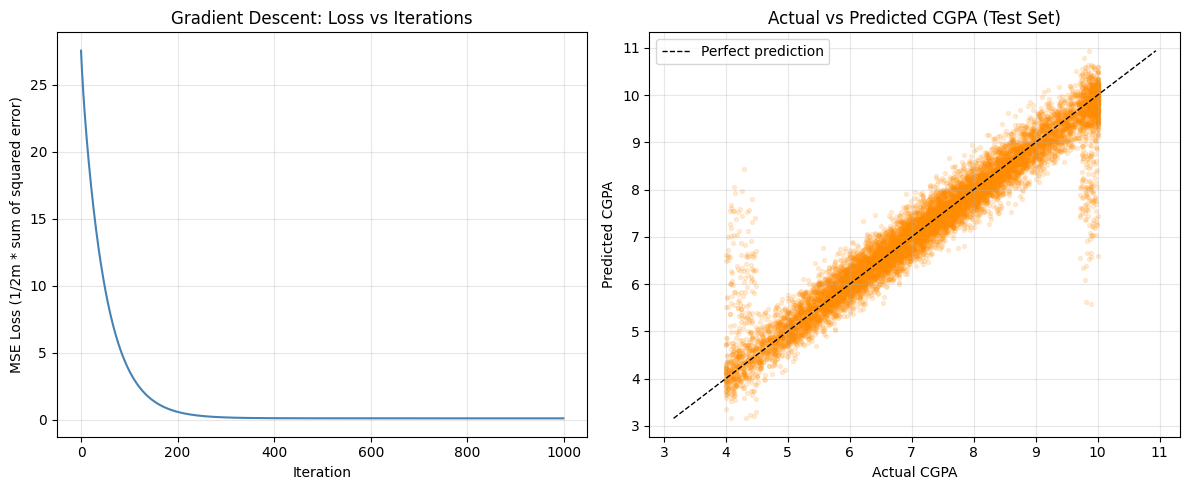

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# (a) Gradient descent loss curve - shows convergence over iterations
axes[0].plot(range(len(losses)), losses, color="steelblue")
axes[0].set_title("Gradient Descent: Loss vs Iterations")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE Loss (1/2m * sum of squared error)")
axes[0].grid(alpha=0.3)
# (b) Actual vs Predicted CGPA on the test set
axes[1].scatter(y_test, y_pred, alpha=0.15, s=8, color="darkorange")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, color="black", linestyle="--", linewidth=1, label="Perfect prediction")
axes[1].set_title("Actual vs Predicted CGPA (Test Set)")
axes[1].set_xlabel("Actual CGPA")
axes[1].set_ylabel("Predicted CGPA")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("gradient_descent_plots.png", dpi=150)
print("\nSaved plots to gradient_descent_plots.png")
plt.show()

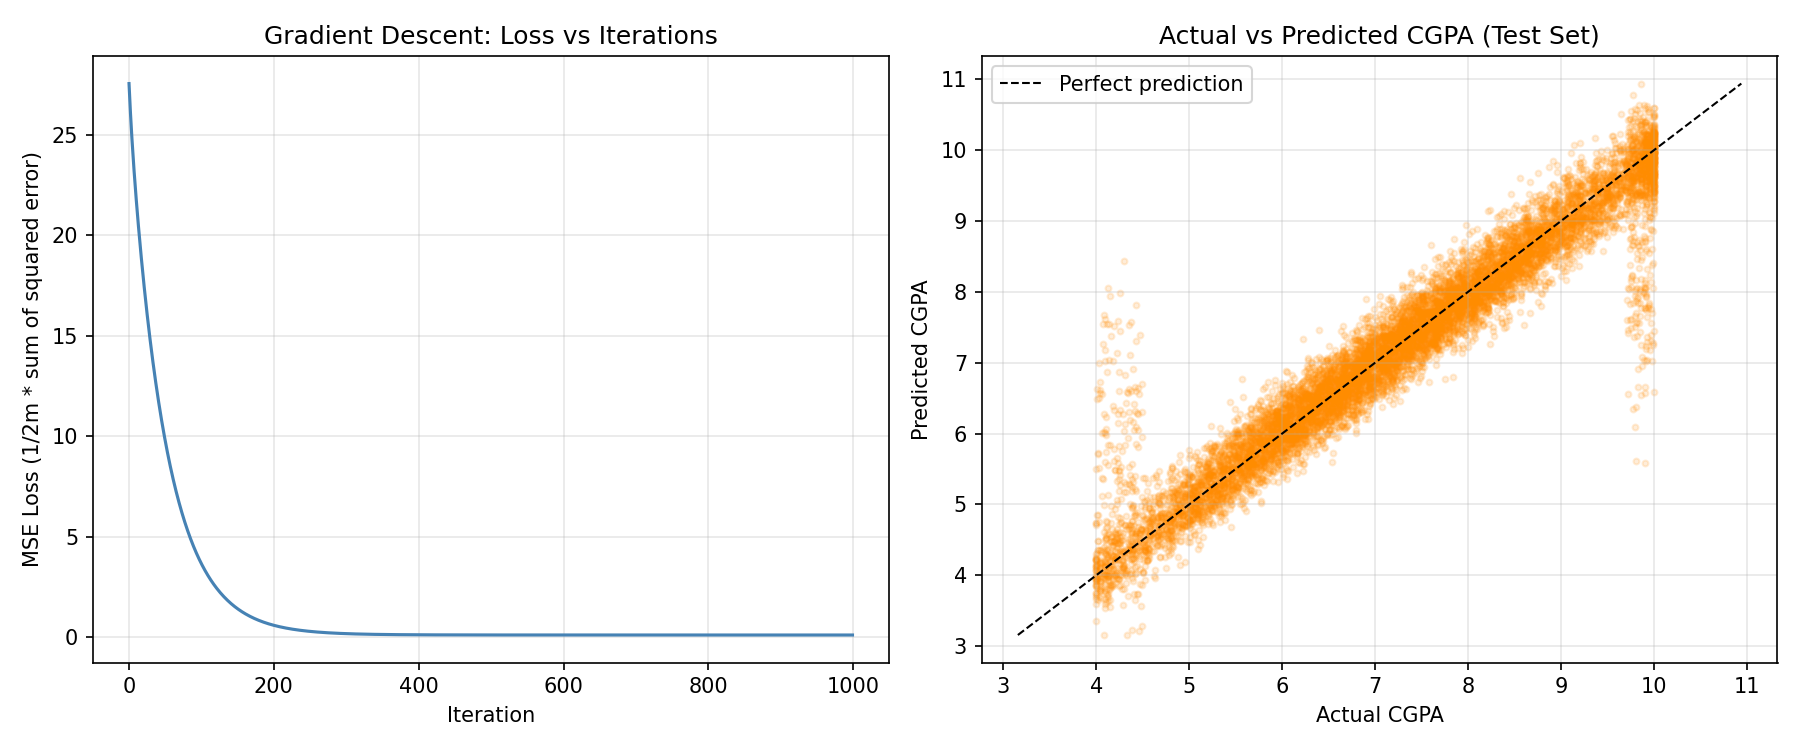